# 07 - 专业图纸渲染

**目标**：用 matplotlib + geopandas 渲染专业规划图纸。

**图纸要素**：
- 标题（中文）
- 图例（专业规划色系）
- 比例尺
- 指北针
- 来源标注
- "临时模拟"水印
- 300dpi PNG 输出

**学习要点**：
- matplotlib 高级布局
- 专业规划色系
- 图纸标注体系
- 中文字体配置

In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import numpy as np
from shapely.geometry import Polygon, LineString

from src.projection import transform_geometry, CRS_4326, CRS_4548
from src.generation import (
    subdivide_boundary,
    assign_land_use,
    LAND_USE_COLORS,
    LAND_USE_LABELS,
)
from src.visualization import (
    plot_land_use,
    add_scale_bar,
    add_north_arrow,
    _setup_chinese_font,
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Check available Chinese fonts
chinese_fonts = [
    'Heiti SC', 'STHeiti', 'Songti SC', 'PingFang SC',
    'Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'STSong'
]

print('Available Chinese fonts:')
for font_name in chinese_fonts:
    try:
        fm.findfont(font_name, fallback_to_default=False)
        print(f'  ✓ {font_name}')
    except Exception:
        print(f'  ✗ {font_name} — not found')

print()
selected_font = _setup_chinese_font()
print(f'Selected font: {selected_font}')

findfont: Failed to find font weight normal, now using 300.


Available Chinese fonts:
  ✓ Heiti SC
  ✓ STHeiti
  ✓ Songti SC
  ✓ PingFang SC
  ✗ Microsoft YaHei — not found
  ✗ SimHei — not found
  ✓ Arial Unicode MS
  ✓ STSong

Selected font: Heiti SC


In [3]:
# Prepare data
gdf_all = gpd.read_file('../data/haidian-boundary.geojson')
site = gdf_all[gdf_all['id'] == 'PROV-SITE-001'].iloc[0]
boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)

cells = subdivide_boundary(boundary_4548, n_rows=20, n_cols=15)
land_use_gdf = assign_land_use(cells, random_seed=42)

print(f'Data prepared: {len(land_use_gdf)} parcels')

Data prepared: 278 parcels


## 图纸 1: 用地规划图（使用封装函数）

In [4]:
output_file = plot_land_use(
    land_use_gdf,
    boundary_4548,
    title='Haidian AI Belt — 用地规划图（模拟数据）',
    output_path='../outputs/land_use_plan.png',
    dpi=300,
)

print(f'Figure saved to: {output_file}')

findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


Figure saved to: ../outputs/land_use_plan.png


## 图纸 2: 自定义图纸 — 带道路叠加

展示如何在基本用地图上叠加道路网络和其他图层。

In [5]:
# Generate road network
def generate_grid_roads_gdf(boundary_poly, spacing_m, road_class, road_name):
    """Generate road network as GeoDataFrame."""
    minx, miny, maxx, maxy = boundary_poly.bounds
    records = []
    
    # Vertical lines
    x = minx
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        clipped = line.intersection(boundary_poly)
        if not clipped.is_empty:
            if clipped.geom_type == 'LineString':
                records.append({'road_class': road_class, 'road_name': road_name, 'geometry': clipped})
            elif clipped.geom_type == 'MultiLineString':
                for seg in clipped.geoms:
                    records.append({'road_class': road_class, 'road_name': road_name, 'geometry': seg})
        x += spacing_m
    
    # Horizontal lines
    y = miny
    while y <= maxy:
        line = LineString([(minx, y), (maxx, y)])
        clipped = line.intersection(boundary_poly)
        if not clipped.is_empty:
            if clipped.geom_type == 'LineString':
                records.append({'road_class': road_class, 'road_name': road_name, 'geometry': clipped})
            elif clipped.geom_type == 'MultiLineString':
                for seg in clipped.geoms:
                    records.append({'road_class': road_class, 'road_name': road_name, 'geometry': seg})
        y += spacing_m
    
    return gpd.GeoDataFrame(records, crs='EPSG:4548')

In [6]:
# Generate roads
roads_secondary = generate_grid_roads_gdf(boundary_4548, 1200, 'secondary', '次干道')
roads_branch = generate_grid_roads_gdf(boundary_4548, 600, 'branch', '支路')
roads_slow = generate_grid_roads_gdf(boundary_4548, 250, 'slow', '慢行道')

print(f'Roads: secondary={len(roads_secondary)}, branch={len(roads_branch)}, slow={len(roads_slow)}')

Roads: secondary=10, branch=19, slow=44


findfont: Failed to find font weight bold, now using 400.


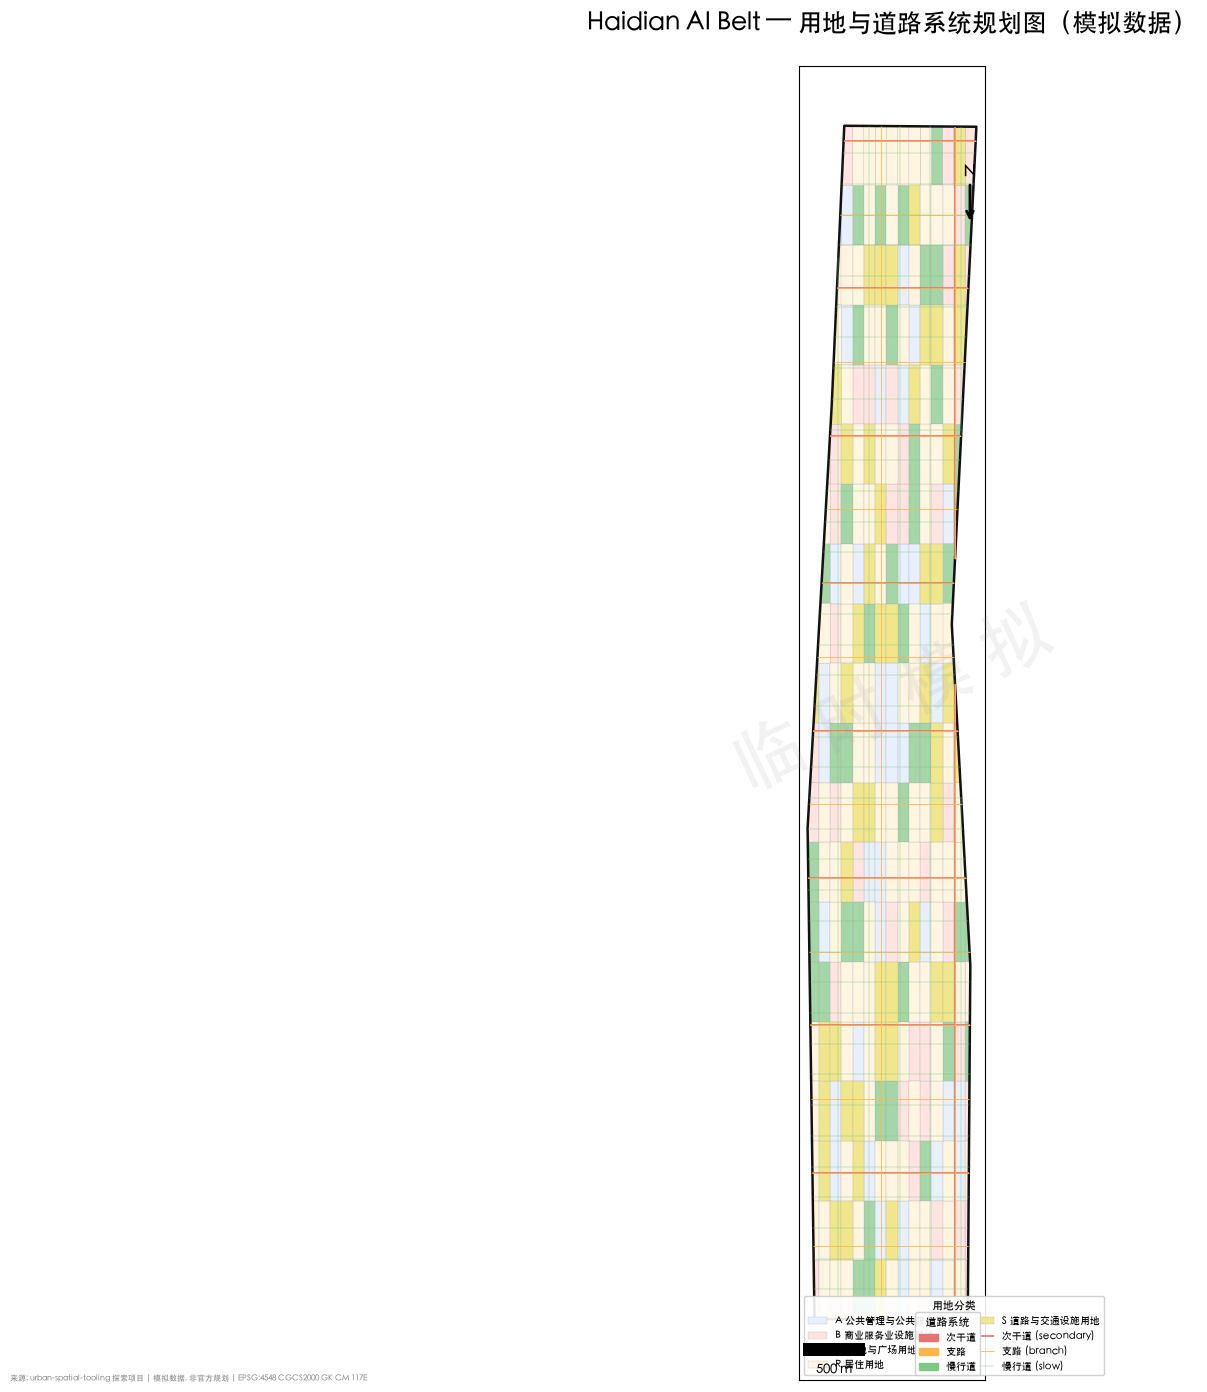

Figure saved to: ../outputs/land_use_with_roads.png


In [7]:
# Create custom figure
_setup_chinese_font()

fig, ax = plt.subplots(figsize=(18, 14))

# 1. Land use parcels (background)
for code in sorted(land_use_gdf['land_use_code'].unique()):
    subset = land_use_gdf[land_use_gdf['land_use_code'] == code]
    color = LAND_USE_COLORS.get(code, '#CCCCCC')
    label = LAND_USE_LABELS.get(code, code)
    subset.plot(ax=ax, color=color, edgecolor='#AAAAAA', linewidth=0.2, label=label)

# 2. Road network overlay
road_styles = [
    (roads_secondary, '#E57373', 1.2, '次干道 (secondary)'),
    (roads_branch, '#FFB74D', 0.6, '支路 (branch)'),
    (roads_slow, '#81C784', 0.3, '慢行道 (slow)'),
]
for roads, color, lw, label in road_styles:
    roads.plot(ax=ax, color=color, linewidth=lw, label=label)

# 3. Boundary
gpd.GeoSeries([boundary_4548]).plot(
    ax=ax, facecolor='none', edgecolor='#111111', linewidth=1.8
)

# 4. Title
ax.set_title('Haidian AI Belt — 用地与道路系统规划图（模拟数据）', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

# 5. Legend — two columns: land use (left), roads (right)
legend1 = ax.legend(
    loc='lower left', fontsize=7, framealpha=0.9, ncol=2,
    title='用地分类', title_fontsize=8
)
ax.add_artist(legend1)

legend2_patches = [
    mpatches.Patch(color='#E57373', label='次干道'),
    mpatches.Patch(color='#FFB74D', label='支路'),
    mpatches.Patch(color='#81C784', label='慢行道'),
]
ax.legend(handles=legend2_patches, loc='lower right', fontsize=7, framealpha=0.9,
          title='道路系统', title_fontsize=8)

# 6. Scale bar and north arrow
add_scale_bar(ax, ax.transData, length_m=500)
add_north_arrow(ax)

# 7. Source note
fig.text(
    0.01, 0.01,
    '来源: urban-spatial-tooling 探索项目 | 模拟数据, 非官方规划 | EPSG:4548 CGCS2000 GK CM 117E',
    fontsize=6, color='#888888', ha='left'
)

# 8. Watermark
fig.text(
    0.5, 0.5,
    '临 时 模 拟',
    fontsize=52, color='#999999', alpha=0.12,
    ha='center', va='center', rotation=25,
    transform=fig.transFigure
)

plt.tight_layout()
fig.savefig('../outputs/land_use_with_roads.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to: ../outputs/land_use_with_roads.png')

## 图纸 3: 指标证据链图

将指标计算过程可视化。

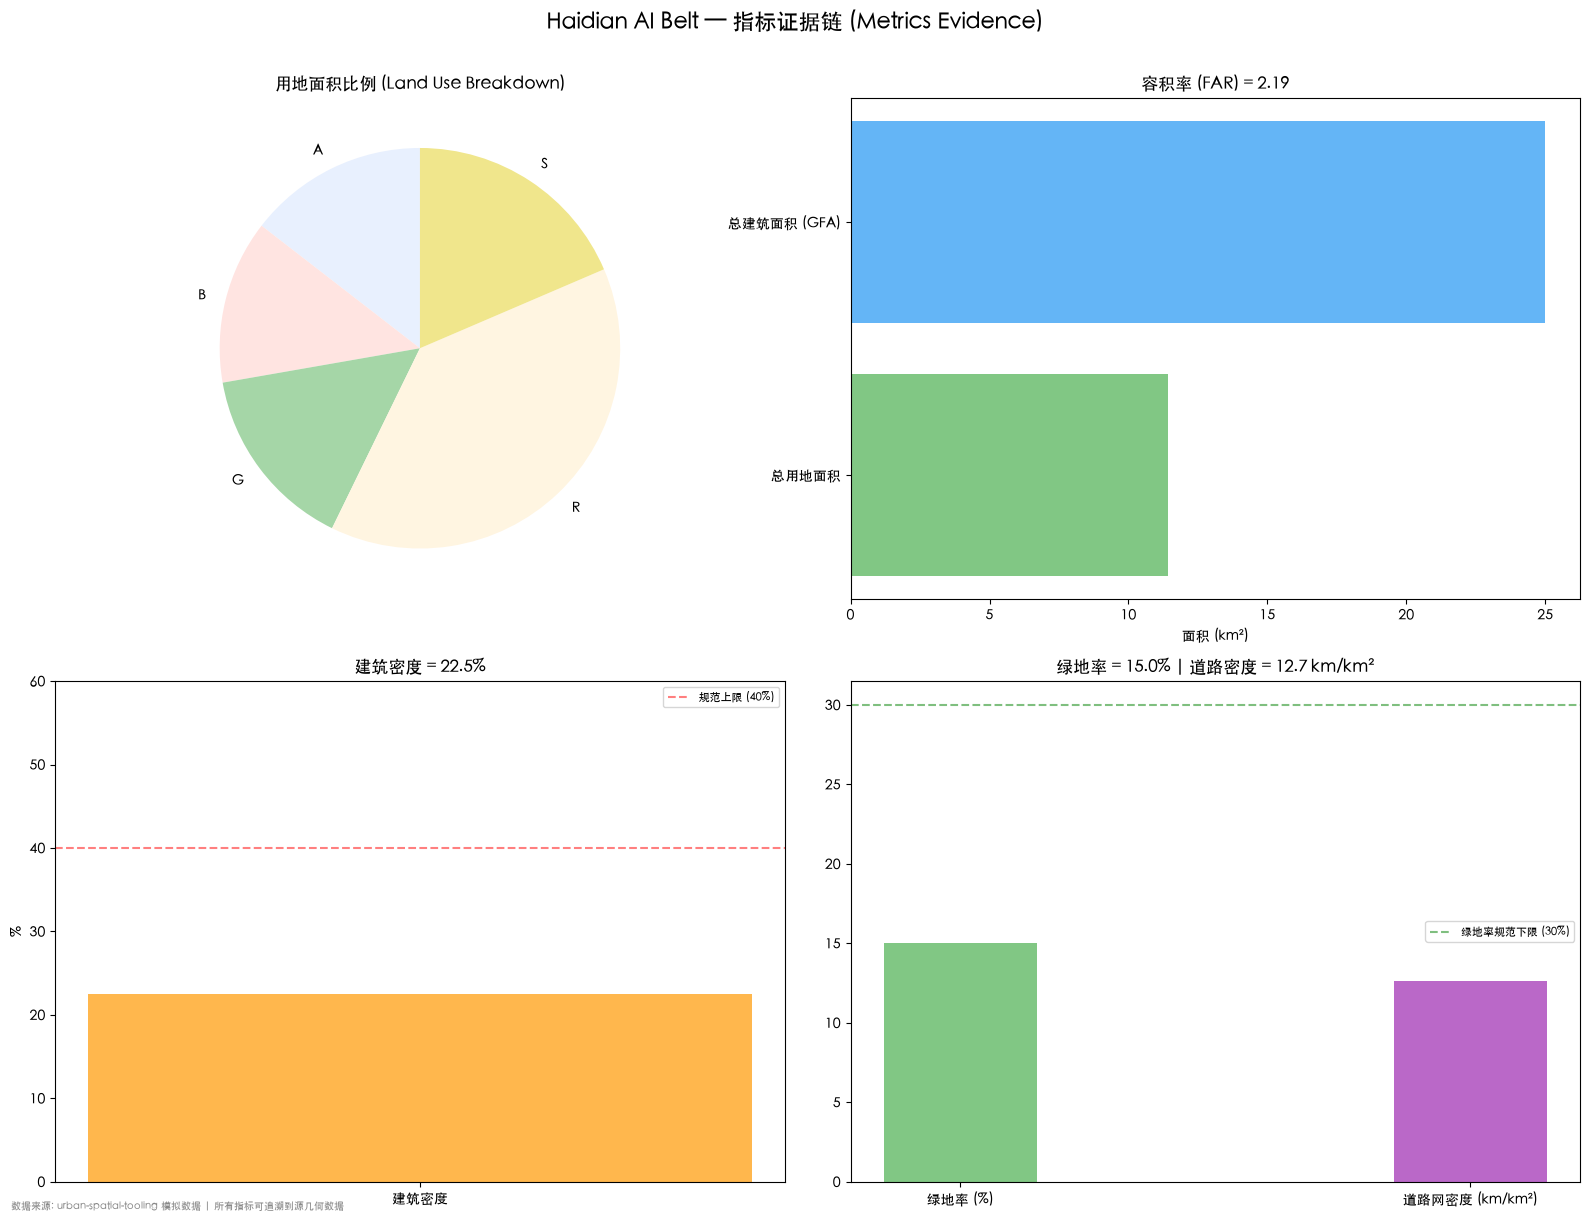

Figure saved to: ../outputs/metrics_evidence.png


In [8]:
import json

# Load metrics
with open('../outputs/metrics.json', 'r', encoding='utf-8') as f:
    metrics = json.load(f)

# Create evidence figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Area breakdown (pie chart)
ax1 = axes[0][0]
lu_data = metrics['land_use']['area_by_code']
labels = [f"{code}" for code in lu_data.keys()]
sizes = [v['pct'] for v in lu_data.values()]
colors = [LAND_USE_COLORS.get(code, '#CCCCCC') for code in lu_data.keys()]
wedges, texts = ax1.pie(sizes, labels=labels, colors=colors, startangle=90)
ax1.set_title('用地面积比例 (Land Use Breakdown)', fontsize=12, fontweight='bold')

# Panel 2: FAR calculation trace
ax2 = axes[0][1]
far = metrics['metrics']['far']['value']
gfa = metrics['metrics']['far']['total_gfa_sqm'] / 1_000_000
site_area_val = metrics['site']['area_km2']
ax2.barh(['总用地面积', '总建筑面积 (GFA)'], [site_area_val, gfa], color=['#81C784', '#64B5F6'])
ax2.set_title(f'容积率 (FAR) = {far:.2f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('面积 (km²)')

# Panel 3: Building density
ax3 = axes[1][0]
bd = metrics['metrics']['building_density']['value_pct']
ax3.bar(['建筑密度'], [bd], color='#FFB74D', width=0.3)
ax3.axhline(y=40, color='r', linestyle='--', alpha=0.5, label='规范上限 (40%)')
ax3.set_ylim(0, max(60, bd + 10))
ax3.set_ylabel('%')
ax3.set_title(f'建筑密度 = {bd:.1f}%', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8)

# Panel 4: Green ratio + Road density
ax4 = axes[1][1]
gr = metrics['metrics']['green_ratio']['value_pct']
rd = metrics['metrics']['road_density']['value_km_per_km2']
ax4.bar(['绿地率 (%)', '道路网密度 (km/km²)'], [gr, rd], color=['#81C784', '#BA68C8'], width=0.3)
ax4.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='绿地率规范下限 (30%)')
ax4.set_title(f'绿地率 = {gr:.1f}% | 道路密度 = {rd:.1f} km/km²', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8)

fig.suptitle('Haidian AI Belt — 指标证据链 (Metrics Evidence)', fontsize=16, fontweight='bold', y=1.01)
fig.text(0.01, 0.01, '数据来源: urban-spatial-tooling 模拟数据 | 所有指标可追溯到源几何数据',
         fontsize=7, color='#888888')

plt.tight_layout()
fig.savefig('../outputs/metrics_evidence.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to: ../outputs/metrics_evidence.png')

In [ ]:
# 图纸 4: 总体概念图 (Site Overview) — 区位、范围、周边关系
# 统筹研究范围作背景, 总体设计范围高亮, 重点区域示意, 周边地理参照(示意位置, 非精确)
from shapely.geometry import Point

_setup_chinese_font()

# 三个范围层级 (EPSG:4548)
gdf_research = gdf_all[gdf_all['id'] == 'PROV-RESEARCH-001']
gdf_key_scope = gdf_all[gdf_all['id'] == 'PROV-KEY-SCOPE-001']
research_4548 = transform_geometry(gdf_research.iloc[0].geometry, CRS_4326, CRS_4548)
key_scope_4548 = transform_geometry(gdf_key_scope.iloc[0].geometry, CRS_4326, CRS_4548)

fig, ax = plt.subplots(figsize=(16, 12))

# 1. 统筹研究范围 (context backdrop)
gpd.GeoSeries([research_4548]).plot(
    ax=ax, facecolor='#F0F4F8', edgecolor='#8FA3B0', linewidth=1.0,
    hatch='///', label='统筹研究范围'
)

# 2. 重点区域范围 (key detailed design area)
gpd.GeoSeries([key_scope_4548]).plot(
    ax=ax, facecolor='#FFE9E3', edgecolor='#D98A86', linewidth=1.2,
    label='重点区域范围'
)

# 3. 总体设计范围 (site — highlight)
gpd.GeoSeries([boundary_4548]).plot(
    ax=ax, facecolor='#FFD9D0', edgecolor='#C0392B', linewidth=2.2,
    label='总体设计范围 (Site)'
)

# 4. 周边地理参照 — 道路 (示意, 非精确位置)
lat_lo, lat_hi = 39.90, 40.07
lon_lo, lon_hi = 116.26, 116.40
ref_roads = [
    ('京藏高速 G6', 116.336, 'v'),
    ('京新高速 G7', 116.306, 'v'),
    ('学院路', 116.354, 'v'),
    ('北四环', 39.980, 'h'),
    ('北五环', 40.005, 'h'),
]
for name, coord, orient in ref_roads:
    if orient == 'v':
        p1 = transform_geometry(Point(coord, lat_lo), CRS_4326, CRS_4548)
        p2 = transform_geometry(Point(coord, lat_hi), CRS_4326, CRS_4548)
    else:
        p1 = transform_geometry(Point(lon_lo, coord), CRS_4326, CRS_4548)
        p2 = transform_geometry(Point(lon_hi, coord), CRS_4326, CRS_4548)
    ax.plot([p1.x, p2.x], [p1.y, p2.y], color='#9AA7B0', linestyle='--', linewidth=0.9, zorder=3)
    ax.text((p1.x + p2.x) / 2, (p1.y + p2.y) / 2, name,
            fontsize=7.5, color='#6B7A84', ha='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8), zorder=4)

# 5. 周边地理参照 — 地名 (示意, 非精确位置)
ref_places = [
    ('上地', 116.325, 40.035),
    ('西二旗', 116.305, 40.060),
    ('中关村软件园', 116.300, 40.045),
    ('五道口', 116.337, 39.993),
    ('清河', 116.348, 40.021),
]
for name, lon, lat in ref_places:
    p = transform_geometry(Point(lon, lat), CRS_4326, CRS_4548)
    ax.plot(p.x, p.y, 'o', color='#444444', markersize=3.5, zorder=5)
    ax.annotate(name, (p.x, p.y), xytext=(7, 7), textcoords='offset points',
                fontsize=9, fontweight='bold', color='#444444', zorder=5)

# 视图范围: 略大于统筹研究范围 (context window)
c1 = transform_geometry(Point(lon_lo, lat_lo), CRS_4326, CRS_4548)
c2 = transform_geometry(Point(lon_hi, lat_hi), CRS_4326, CRS_4548)
ax.set_xlim(c1.x, c2.x)
ax.set_ylim(c1.y, c2.y)

ax.set_title('Haidian AI Belt — 总体概念图 (Site Overview)（模拟数据）',
             fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.text(0.5, 0.02, '周边地理参照为示意位置 (approximate), 非精确标注',
        transform=ax.transAxes, fontsize=7, color='#888888', ha='center')

add_scale_bar(ax, ax.transData, length_m=2000)
add_north_arrow(ax)

fig.text(0.01, 0.01,
         '来源: urban-spatial-tooling 探索项目 | 模拟数据, 非官方规划 | EPSG:4548 CGCS2000 GK CM 117E',
         fontsize=6, color='#888888', ha='left')
fig.text(0.5, 0.5, '临 时 模 拟',
         fontsize=52, color='#999999', alpha=0.12,
         ha='center', va='center', rotation=25, transform=fig.transFigure)

plt.tight_layout()
fig.savefig('../outputs/site-overview.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to: ../outputs/site-overview.png')

In [ ]:
# 图纸 5: 重点区索引图 (Key Areas) — 三处重点片区
_setup_chinese_font()

KEY_AREA_STYLE = {
    'PROV-KEY-001': ('众智园AI自主创新加速区', '#E57373'),
    'PROV-KEY-002': ('北京AI原点社区', '#64B5F6'),
    'PROV-KEY-003': ('大钟寺AI产业聚集区', '#FFB74D'),
}

fig, ax = plt.subplots(figsize=(10, 16))

# 1. 总体设计范围 (light background)
gpd.GeoSeries([boundary_4548]).plot(
    ax=ax, facecolor='#F7F7F7', edgecolor='#111111', linewidth=1.8
)

# 2. 三处重点片区 + 标注
key_areas = gdf_all[gdf_all['layer'] == 'KEY_AREA']
legend_handles = []
for _, feature in key_areas.iterrows():
    kid = feature['id']
    name, color = KEY_AREA_STYLE.get(kid, (feature['name_zh'], '#CCCCCC'))
    geom_4548 = transform_geometry(feature.geometry, CRS_4326, CRS_4548)
    gpd.GeoSeries([geom_4548]).plot(
        ax=ax, facecolor=color, edgecolor='#333333', linewidth=1.2, alpha=0.85
    )
    centroid = geom_4548.centroid
    ax.annotate(
        name,
        (centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=11, fontweight='bold', color='#222222',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#666666', alpha=0.92),
        zorder=6,
    )
    legend_handles.append(mpatches.Patch(color=color, label=name))

# 3. 重点区域范围总边界 (dashed index outline, on top)
gpd.GeoSeries([key_scope_4548]).plot(
    ax=ax, facecolor='none', edgecolor='#C0392B', linewidth=1.2, linestyle='--', zorder=5
)

# 4. 图名、图例与图纸要素
ax.set_title('Haidian AI Belt — 重点区索引图 (Key Areas)（模拟数据）',
             fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([])

ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.95,
          title='重点片区', title_fontsize=10)

add_scale_bar(ax, ax.transData, length_m=500)
add_north_arrow(ax)

fig.text(0.01, 0.01,
         '来源: urban-spatial-tooling 探索项目 | 模拟数据, 非官方规划 | EPSG:4548 CGCS2000 GK CM 117E',
         fontsize=6, color='#888888', ha='left')
fig.text(0.5, 0.5, '临 时 模 拟',
         fontsize=52, color='#999999', alpha=0.12,
         ha='center', va='center', rotation=25, transform=fig.transFigure)

plt.tight_layout()
fig.savefig('../outputs/key-areas.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved to: ../outputs/key-areas.png')

## 验证输出文件

In [9]:
import os

outputs_dir = '../outputs'
print('Generated output files:')
for f in sorted(os.listdir(outputs_dir)):
    path = os.path.join(outputs_dir, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {f:40s} {size_kb:8.1f} KB')

Generated output files:
  10-insolation-heatmap.png                    83.1 KB
  10-shadow-single.png                         52.0 KB
  10-solar-path.png                           131.1 KB
  10-spacing-vs-height.png                     94.3 KB
  11-building-compliance.png                  134.7 KB
  11-cross-section.png                         85.1 KB
  11-height-envelope-2d.png                   119.1 KB
  11-view-corridor-profile.png                119.3 KB
  12-lid-sizing.png                            98.7 KB
  12-parcel-runoff-map.png                     63.5 KB
  12-sensitivity.png                          129.3 KB
  12-sponge-metrics.json                        0.7 KB
  12-storage-by-control-rate.png               71.9 KB
  13-accessibility-heatmap.png                137.7 KB
  13-buffer-map.png                           598.0 KB
  13-network-isochrones.png                   337.5 KB
  14-footprints.geojson                        11.7 KB
  14-method1-buffer-envelope.png         

## 总结

- 成功渲染了多张专业级规划图纸
- 实现了标题、图例、比例尺、指北针、来源标注、水印等专业要素
- 支持中文字体（macOS: Heiti SC / PingFang SC）
- 300dpi PNG 输出
- `src/visualization.py` 提供了可复用的绘图函数
- 全部 6 个探索步骤完成